In [81]:
import warnings
warnings.filterwarnings('ignore')

In [82]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [83]:
pd.set_option('display.max_columns', 100)

In [84]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [85]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,218,Democrats
1,224,Democrats
2,237,Democrats
3,221,Democrats
4,204,Republicans
...,...,...
19995,226,Democrats
19996,230,Democrats
19997,226,Democrats
19998,228,Democrats


In [86]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,109,1,0.005,Republicans
1,148,1,0.005,Republicans
2,154,1,0.005,Republicans
3,162,3,0.015,Republicans
4,163,2,0.010,Republicans


In [87]:
np.unique(seat_sims['seats']).shape[0]

184

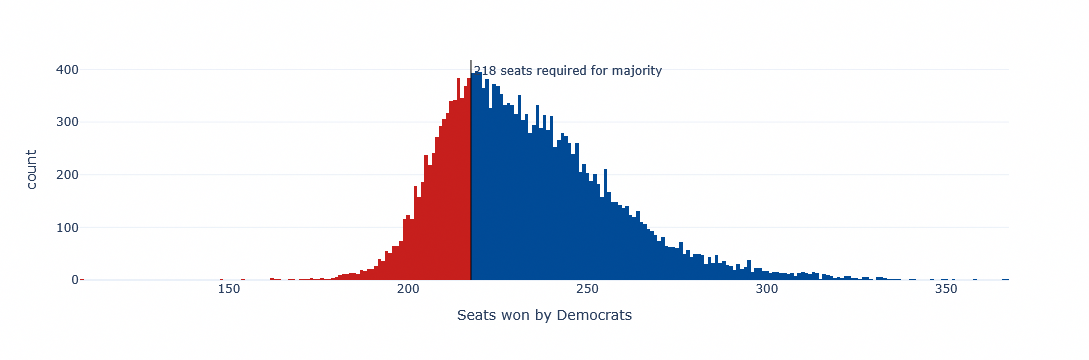

In [88]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [89]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-08-30,229.365800,US House,seats
1,2026-08-30,66.120000,US House,chance
2,2026-08-30,22.784344,US House,seats_sd
3,2026-08-30,44.972806,AK-AL,y_pred
4,2026-08-30,3.555839,AK-AL,y_pred_sd


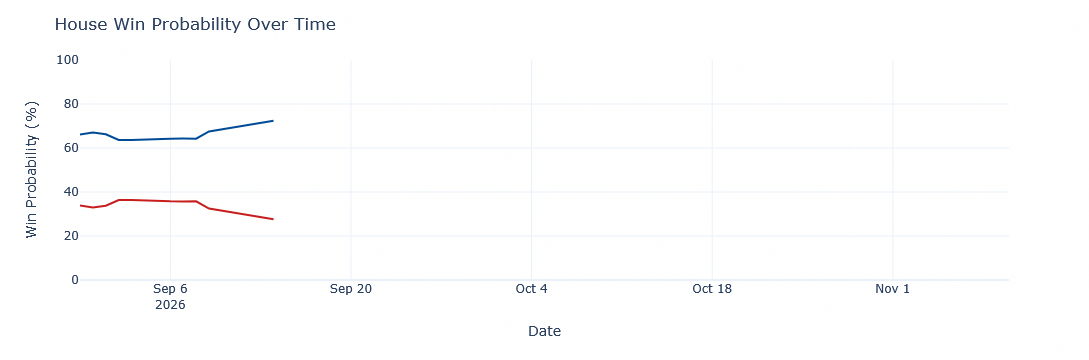

In [90]:
chance_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="House Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

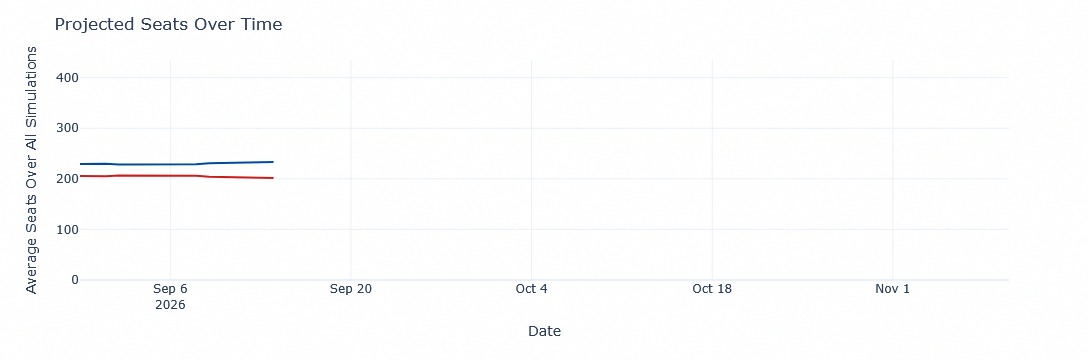

In [91]:
seats_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 435 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 435]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [92]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [93]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [94]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,19950,19951,19952,19953,19954,19955,19956,19957,19958,19959,19960,19961,19962,19963,19964,19965,19966,19967,19968,19969,19970,19971,19972,19973,19974,19975,19976,19977,19978,19979,19980,19981,19982,19983,19984,19985,19986,19987,19988,19989,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-3.913066,-5.928390,-2.387260,-8.995906,-12.237576,2.653009,-0.830017,-6.195440,-4.456637,-5.210366,-3.444585,-6.149187,-3.710127,-5.148547,-4.052827,-6.247934,-1.845321,-3.161495,-2.339632,-3.084232,-3.114194,-6.070331,-7.038246,-3.586079,-4.146960,-1.762740,-6.154732,-2.499335,-8.213418,-4.303380,-6.189041,-6.349792,-3.616737,-7.837443,-3.010060,-10.046537,-2.518545,-12.845055,4.939567,-13.989870,5.188071,4.549909,-1.693912,-7.175566,-4.076815,-4.017531,-0.077581,-3.727973,-6.794479,-1.354753,...,-3.359187,-10.242906,-1.280284,-14.340797,2.663289,-6.729026,-5.581882,-3.635676,-0.735202,-3.232188,-4.065052,-0.707157,-8.041568,-0.171688,-7.457759,-3.252639,-3.529562,-2.566691,-3.663758,-8.702146,-2.018133,-2.124579,-11.273019,-6.348130,-1.410920,-8.268566,-6.628383,-2.261043,-6.451237,-3.236733,-8.364629,0.833525,-5.044597,2.172793,1.688388,-7.856172,1.025697,-3.574176,-3.320064,-5.543227,-8.901365,-9.494675,-13.558318,-5.476455,-2.965581,-7.433049,-5.399922,-5.534050,-8.633541,-5.110030
AL-01,-15.922790,-12.396406,-12.321700,-15.024632,-18.230521,-9.291306,-9.922831,-16.604159,-12.425129,-13.303964,-16.211092,-14.444535,-16.607610,-8.745286,-13.791222,-11.064445,-12.780959,-7.758120,-17.584666,-14.178065,-14.818971,-13.636428,-13.282568,-13.598672,-11.995899,-12.773803,-13.113160,-12.568167,-14.243300,-12.569395,-15.426294,-16.776135,-16.238137,-21.140788,-9.539538,-15.875200,-11.437268,-25.221459,-4.436755,-18.104448,-5.707906,-2.774419,-8.400899,-17.282299,-12.611902,-16.911442,-12.572017,-12.301609,-12.126406,-9.917828,...,-12.884987,-15.557742,-10.534909,-19.302617,-6.884949,-13.125116,-11.025350,-14.858257,-13.834203,-10.110180,-14.249105,-8.671891,-17.342376,-9.921772,-17.890077,-16.930440,-11.244861,-11.098111,-15.961231,-21.503204,-7.058264,-10.984853,-19.924451,-11.902753,-11.940065,-15.978157,-14.645155,-8.742572,-15.498670,-9.866507,-15.611462,-8.649145,-18.160702,-7.058050,-7.807854,-18.583762,-8.367656,-15.275995,-13.207472,-15.597076,-18.266744,-21.586230,-24.338049,-14.040042,-14.421405,-14.115469,-13.512592,-14.954146,-10.425101,-16.264139
AL-02,-5.663463,0.647753,-1.196247,0.641775,-3.815283,-3.857624,-1.787695,-4.860642,2.034219,-2.831195,0.605437,-6.245605,0.120260,-6.617919,0.217531,-8.710712,4.971749,-2.426370,0.747340,-3.263224,2.387173,-7.392475,-3.051572,-1.758770,-2.942941,1.145392,0.378721,-2.065989,3.345790,-0.633816,1.454080,-3.067918,-7.272363,-7.468679,1.619620,-7.054465,2.166789,-6.193226,-1.545244,-7.426223,1.855312,-0.813831,2.383270,-1.988494,3.642619,-2.974776,2.788930,-1.603819,-3.228594,4.522683,...,0.398091,-0.944980,-5.010653,-4.345018,2.477376,-8.136310,-2.604011,-0.245461,-5.834445,2.443440,-2.101082,-1.292329,-2.711438,-4.726218,-0.718408,-0.715592,-0.890774,0.293046,-2.606095,-3.179877,7.806298,3.967607,-4.184382,-0.933713,-5.059291,-6.268410,-1.079831,1.575924,1.020644,1.179437,-2.895900,0.068044,-1.957216,1.468887,2.684640,1.812131,-0.041710,-1.338037,-1.989375,1.818942,-3.918690,-8.415143,-4.665637,-2.518583,-1.456202,1.097113,-2.303417,-6.230070,1.186290,-6.223667
AL-03,-20.676877,-22.089902,-19.027649,-25.364786,-30.172483,-14.008587,-16.917528,-17.328300,-22.138245,-19.653563,-19.556127,-18.974193,-21.677547,-16.907142,-21.969720,-18.448726,-20.710371,-20.548131,-21.418748,-17.863703,-22.338988,-21.161142,-20.716655,-19.424060,-22.983605,-16.803343,-22.718769,-21.267352,-25.142479,-21.180321,-20.404630,-19.582724,-20.783422,-24.339056,-18.993904,-18.288035,-18.893959,-27.415620,-13.417970,-28.362926,-15.423813,-10.914132,-17.571469,-24

In [95]:
sim_corr = post_untransp.corr()

In [96]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,AR-03,AR-04,AZ-01,AZ-02,AZ-03,AZ-04,AZ-05,AZ-06,AZ-07,AZ-08,AZ-09,CA-01,CA-02,CA-03,CA-05,CA-06,CA-08,CA-09,CA-10,CA-13,CA-15,CA-16,CA-17,CA-18,CA-19,CA-20,CA-21,CA-22,CA-23,CA-24,CA-25,CA-26,CA-27,CA-28,CA-30,CA-31,CA-32,CA-33,CA-35,CA-36,...,TX-25,TX-26,TX-27,TX-28,TX-29,TX-30,TX-31,TX-32,TX-33,TX-34,TX-35,TX-36,TX-37,TX-38,UT-01,UT-02,UT-03,UT-04,VA-01,VA-02,VA-03,VA-04,VA-05,VA-06,VA-07,VA-08,VA-09,VA-10,VA-11,VT-AL,WA-01,WA-02,WA-03,WA-04,WA-05,WA-06,WA-07,WA-08,WA-09,WA-10,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.727338,0.505327,0.752860,0.739799,0.728769,0.746331,0.515076,0.747757,0.750932,0.750770,0.748293,0.515527,0.511648,0.513111,0.528809,0.714806,0.730724,0.738856,0.731649,0.752332,0.715713,0.526106,0.537622,0.751848,0.744876,0.587674,0.530325,0.534072,0.530623,0.504864,0.716250,0.588454,0.527511,0.527643,0.718929,0.530114,0.751085,0.743578,0.535735,0.530040,0.719146,0.512091,0.534443,0.507964,0.548127,0.571596,0.531035,0.584878,0.534600,...,0.747390,0.731426,0.566463,0.528219,0.528576,0.714691,0.755327,0.712766,0.554257,0.529822,0.716351,0.547466,0.515740,0.509885,0.513843,0.743607,0.730190,0.732991,0.758084,0.571670,0.530316,0.508068,0.733919,0.748383,0.509248,0.534268,0.745570,0.505203,0.714540,0.547999,0.535246,0.531834,0.514665,0.715485,0.559812,0.506774,0.523533,0.525175,0.589547,0.520853,0.746754,0.567803,0.589892,0.746193,0.755356,0.714178,0.732855,0.745465,0.731510,0.714552
AL-01,0.727338,1.000000,0.511680,0.752292,0.744695,0.739691,0.754652,0.522240,0.746006,0.749922,0.751849,0.749515,0.518097,0.515376,0.517095,0.533235,0.715854,0.732067,0.740382,0.733280,0.749514,0.714348,0.525956,0.539464,0.753970,0.738131,0.593543,0.536123,0.535099,0.533431,0.512497,0.712267,0.592958,0.530561,0.529992,0.717726,0.530926,0.753830,0.739781,0.533704,0.532543,0.712412,0.515963,0.535509,0.509150,0.559217,0.580090,0.535504,0.589546,0.535924,...,0.746090,0.729236,0.575191,0.530538,0.533035,0.708409,0.755777,0.715018,0.558191,0.536156,0.714209,0.553211,0.515419,0.521181,0.518933,0.746324,0.731740,0.732940,0.753976,0.570398,0.535113,0.512246,0.727715,0.743212,0.509657,0.535862,0.748892,0.507571,0.715937,0.548880,0.536213,0.534288,0.519274,0.718581,0.564601,0.510195,0.526004,0.526296,0.597649,0.521309,0.747346,0.570610,0.593424,0.747477,0.754748,0.719290,0.733744,0.748321,0.726254,0.717866
AL-02,0.505327,0.511680,1.000000,0.519765,0.510753,0.500572,0.521700,0.714209,0.516168,0.520219,0.523084,0.521062,0.697780,0.684568,0.688210,0.712894,0.651017,0.500262,0.509889,0.499573,0.520714,0.651176,0.717748,0.724088,0.529623,0.509026,0.604613,0.715477,0.722841,0.545223,0.689650,0.649621,0.598015,0.716343,0.714223,0.653376,0.717190,0.520195,0.510981,0.722971,0.721544,0.655176,0.694176,0.715788,0.686433,0.570750,0.587235,0.720888,0.601036,0.721939,...,0.517151,0.500742,0.582928,0.716774,0.710747,0.654189,0.521882,0.658229,0.565244,0.712939,0.658435,0.555572,0.698355,0.697328,0.691614,0.517436,0.499135,0.506590,0.521304,0.574053,0.713014,0.686615,0.502765,0.511497,0.688468,0.721067,0.516860,0.686809,0.653026,0.559203,0.720373,0.718373,0.695697,0.657929,0.576648,0.687586,0.712397,0.714311,0.607607,0.701634,0.515310,0.576503,0.605313,0.515659,0.517318,0.653297,0.501745,0.513741,0.493334,0.653166
AL-03,0.752860,0.752292,0.519765,1.000000,0.770425,0.755195,0.776528,0.532297,0.773987,0.777112,0.768867,0.775067,0.525843,0.522072,0.525044,0.540484,0.733257,0.751497,0.757228,0.751075,0.775626,0.735740,0.537735,0.545696,0.775172,0.762066,0.602629,0.543801,0.547065,0.541888,0.519166,0.733874,0.599169,0.539741,0.539919,0.737484,0.538544,0.771459,0.762441,0.542656,0.542593,0.732268,0.523756,0.540463,0.520425,0.564285,0.587306,0.544073,0.600265,0.545926,...,0.771730,0.752046,0.582927,0.537732,0.538545,0.728796,0.776053,0.733993,0.570403,0.543933,0.734235,0.564531,0.527535,0.525119,0.526605,0.766564,0.751125,0.750759,0.778061,0.578275,0.542892,0.519875,0.75044

In [97]:
post.shape

(418, 20000)

In [98]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [99]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:27<00:00, 726.72it/s]


array(['MD-04', 'AL-02', 'NY-17', ..., 'FL-14', 'AL-02', 'NC-11'],
      shape=(20000,), dtype='<U32')

In [100]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-7.380266,1,0,46.957206,0.763704,46.963324,0.763704,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.763704,0.873902,0.006119,-5.663150,-19.716169,1,-39.432338,48.309873,3.540376,31.365,3,41.358561,55.256779
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-38.261918,-45.710827,-1,-91.421653,29.844389,3.537461,0.000,4,22.833704,36.845538
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-58.554013,-47.132870,-1,-94.265741,20.121877,3.572244,0.000,5,13.131961,27.142389


In [101]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.120
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-7.380266,1,0,46.957206,0.763704,46.963324,0.763704,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.763704,0.873902,0.006119,-5.663150,-19.716169,1,-39.432338,48.309873,3.540376,31.365,3,41.358561,55.256779,1.335
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-38.261918,-45.710827,-1,-91.421653,29.844389,3.537461,0.000,4,22.833704,36.845538,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-58.554013,-47.132870,-1,-94.265741,20.121877,3.572244,0.000,5,13.131961,27.142389,0.000


In [102]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
193,193,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",1135198.13,1290223.21,2425421.34,46.804162,53.195838,Michigan,MI-10,76.551128,2.316124,5.150984,0.123322,13.269372,29.340000,-2.765891,-2.592362,-2.635744,99.999226,46.657584,0.987401,-7.380266,0,0,45.000000,0.296926,45.000000,0.296926,East North Central,2026,0.0,0.000000,0.000000,26,2610,0,2190.629568,0.296926,0.544909,-1.460326e-07,2.108778,-3.195838,0,-6.391676,50.623429,3.675237,56.500,194,43.454749,57.921871,3.050
229,229,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,2799701.44,0.00,2799701.44,100.000000,0.000000,North Carolina,NC-11,88.740422,3.902084,0.797632,1.120840,3.305854,24.807640,-7.843347,-4.057125,-5.003681,49.294326,45.192821,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.000000,0.000000,37,3711,2,10000.000000,0.000000,0.000000,0.000000e+00,-2.627096,50.000000,0,100.000000,50.952768,3.676700,60.560,230,43.733697,58.252225,2.995
98,98,FL-22,Pia Dandiya,Casey Askar,False,False,FL,22,"DANDIYA, PIA","ASKAR, CASEY",1965051.29,57760.00,2022811.29,97.144568,2.855432,Florida,FL-22,53.931205,26.984941,3.703933,0.199203,13.186062,27.190634,-0.817400,-4.551960,-3.618320,91.180168,44.697986,0.987401,-7.380266,0,0,46.286766,0.810077,44.430149,0.810077,South Atlantic,2026,0.0,0.000000,0.000000,12,1222,6,9437.067100,0.810077,0.900043,-1.856617e+00,0.143625,47.144568,0,94.289136,51.889495,3.667508,69.920,99,44.744130,59.184868,2.710
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",2396295.54,1423592.37,3819887.91,62.732090,37.267910,California,CA-22,22.131732,64.469110,4.924433,0.538078,6.308791,6.196120,6.443675,-0.178428,1.477097,85.545753,49.071518,0.987401,-7.380266,0,1,48.000000,0.051660,44.000000,0.051660,Pacific,2026,0.0,0.000000,0.000000,6,622,5,3935.315176,0.051660,0.227289,-4.000000e+00,10.334460,12.732090,-1,25.464181,50.972727,3.512078,61.020,38,44.022933,57.849974,2.650
123,123,IA-03,Sarah Trone Garriott,Zach Nunn,False,True,IA,3,"TRONE GARRIOTT, SARAH","NUNN, ZACH",4755754.76,1010301.85,5766056.61,82.478461,17.521539,Iowa,IA-03,86.341081,5.022950,2.732262,0.063009,3.929259,35.410000,-2.445778,-1.482072,-1.722998,77.628515,47.767874,0.987401,-7.380266,0,1,42.000000,0.002002,48.000000,0.002002,West North Central,2026,0.0,0.000000,0.000000,19,1903,0,6802.696551,0.002002,0.044741,6.000000e+00,3.934269,32.478461,-1,64.956922,51.607607,3.579888,67.625,124,44.522986,58.645424,2.625
273,273,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",3706160.25,3186004.97,6892165.22,53.773526,46.226474,New York,NY-17,70.961924,14.978446,4.840493,0.059866,7.686273,48.490000,2.820018,1.029915,1.477441,87.206472,50.279862,0.987401,-7.380266,0,1,45.156078,0.207379,49.869935,0.207379,Mid-Atlantic,2026,0.0,0.000000,0.000000,36,3617,0,2891.592088,0.207379,0.455389,4.713858e+00,10.335148,3.773526,-1,7.547052,51.040313,3.536608,61.950,274,44.127883,58.025989,2.570
289,289,OH-07,Brian Poindexter,Max Miller,False,True,OH,7,"POINDEXTER, BRIAN","MILLER, MAX",439659.22,924384.95,1364044.17,32.232037,67.767963,Ohio,OH-07,89.432935,3.348946,2.187434,0.068208,3.218146,26.556779,-7.118675,-4.823517,-5.397307,83.893826,44.426429,0.9

In [103]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [104]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.120,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-7.380266,1,0,46.957206,0.763704,46.963324,0.763704,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.763704,0.873902,0.006119,-5.663150,-19.716169,1,-39.432338,48.309873,3.540376,31.365,3,41.358561,55.256779,1.335,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-38.261918,-45.710827,-1,-91.421653,29.844389,3.537461,0.000,4,22.833704,36.845538,0.000,Safe R,"<b style=""color:#366bbf;"">Lee McInnis (D)</b> ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-58.554013,-47.132870,-1,-94.265741,20.121877,3.572244,0.000,5,13.131961,27.142389,0.000,Safe R,"<b style=""color:#366bbf;"">Amanda Pusczek (D)</..."


In [105]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.120,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-7.380266,1,0,46.957206,0.763704,46.963324,0.763704,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.763704,0.873902,0.006119,-5.663150,-19.716169,1,-39.432338,48.309873,3.540376,31.365,3,41.358561,55.256779,1.335,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R)


In [106]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.12,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,


In [107]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.120,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.3
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.1
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-7.380266,1,0,46.957206,0.763704,46.963324,0.763704,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.763704,0.873902,0.006119,-5.663150,-19.716169,1,-39.432338,48.309873,3.540376,31.365,3,41.358561,55.256779,1.335,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+3.4


In [108]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.120,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.3,90.105,9.9,90.1,9.9%,90.1%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.1,99.985,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-7.380266,1,0,46.957206,0.763704,46.963324,0.763704,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.763704,0.873902,0.006119,-5.663150,-19.716169,1,-39.432338,48.309873,3.540376,31.365,3,41.358561,55.256779,1.335,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+3.4,68.635,31.4,68.6,31.4%,68.6%


In [109]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.120,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.3,90.105,9.9,90.1,9.9%,90.1%,4.422048
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.1,99.985,0.0,100.0,<1%,>99%,9.228247
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-7.380266,1,0,46.957206,0.763704,46.963324,0.763704,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.763704,0.873902,0.006119,-5.663150,-19.716169,1,-39.432338,48.309873,3.540376,31.365,3,41.358561,55.256779,1.335,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+3.4,68.635,31.4,68.6,31.4%,68.6%,11.084174


In [110]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-7.380266,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-5.530339,-18.764506,-1,-37.529012,45.364461,3.615707,9.895,1,38.308920,52.443883,0.12,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+9.3,90.105,9.9,90.1,9.9%,90.1%,4.422048,D+4.4
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-7.380266,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-27.494017,-38.923019,0,-77.846039,36.441887,3.610716,0.015,2,29.397244,43.527131,0.00,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.1,99.985,0.0,100.0,<1%,>99%,9.228247,D+9.2


In [111]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
413    5507
414    5508
415    5401
416    5402
417    5600
Name: geoid, Length: 418, dtype: int64

In [112]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_24_to_26_swing'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                      x['dem_inc_any'], x['rep_inc_any']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Mike Thompson/Eric J..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Doris Matsui/Mai Van..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Scott Weiner/Connie ..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Lateefah Simon* (D)<..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,True,False,CA,14,6,614,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Aisha Wahab/Melissa ..."


In [113]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_24_to_26_swing'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                       x['dem_inc_any'], x['rep_inc_any']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,NaN,0%,100%,R+100,,"<b style=""color:#366bbf;"">Not Contested (D)</b..."


In [114]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 16)

In [115]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Very Likely R,"<p style=""color:blue;"">9.9%</p>","<p style=""color:red;"">90.1%</p>",R+9.3,D+4.4,0.120
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+27.1,D+9.2,0.000
2,AL-02,Shomari Figures,Rhett Marques,Lean R,"<p style=""color:blue;"">31.4%</p>","<p style=""color:red;"">68.6%</p>",R+3.4,D+11.1,1.335
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+40.3,D+6.7,0.000
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+59.8,D+7.2,0.000


In [116]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

6.133407735482219

In [117]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,Unnamed: 0,vars,x
0,0.0,means_seats_tot,233.562500
1,1.0,chamber_win_chance,72.395000
0,NaN,sv_bias,6.133408


In [118]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [119]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 435 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Unnamed: 0_x,Win Probability,Unnamed: 0_y,Seat Share
0,Democrats,1.0,72.395,0.0,233.5625
1,Republicans,99.0,27.605,435.0,201.4375


In [120]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')